# ❤️ Heart Failure Prediction: ML for Clinical Decision Support

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting heart disease from clinical indicators to support early diagnosis and preventive cardiology  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting heart disease using clinical features (chest pain type, blood pressure, cholesterol, ECG, exercise response). The model supports **clinical decision support** for GPs and cardiologists in identifying high-risk patients.

### Government Policy Context
- **Department of Health & Aged Care** — National Heart Foundation strategy, Medicare Heart Health Check (item 699)
- **AIHW** — Cardiovascular disease surveillance, burden of disease reporting
- **PBS** — Statin/antihypertensive utilisation analytics, cost-effectiveness modelling
- **Primary Health Networks (PHNs)** — Chronic disease screening, GP referral pathways to cardiology
- **CSIRO** — Precision health research, digital health innovation

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High heart disease risk | Urgent cardiology referral, stress test/angiography | GP + cardiologist |
| Moderate risk | Lifestyle intervention, statin consideration, 3-month follow-up | GP + practice nurse |
| Low risk (confident) | Annual Heart Health Check, routine screening | Automated recall system |
| Low risk (risk factors present) | Targeted education (diet, exercise, smoking), 6-month review | Practice nurse |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
# === Data loading ===
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv

Using: /kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv
Loaded: 918 rows x 12 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Age                       | int64      | unique=   50 | nulls=  0 | eg: 40
   1. Sex                       | object     | unique=    2 | nulls=  0 | eg: M
   2. ChestPainType             | object     | unique=    4 | nulls=  0 | eg: ATA
   3. RestingBP                 | int64      | unique=   67 | nulls=  0 | eg: 140
   4. Cholesterol               | int64      | unique=  222 | nulls=  0 | eg: 289
   5. FastingBS                 | int64      | unique=    2 | nulls=  0 | eg: 0
   6. RestingECG                | object     | unique=    3 | nulls=  0 | eg: Normal
   7. MaxHR                     | int64      | unique=  119 | nulls=  0 | eg: 172
   8. ExerciseAngina            | object     | unique=    2 | nulls=  0 | eg: N
   9. Oldpeak                   | float64    | unique=   53 | nulls=  0 | eg: 0.0
  10. ST_Slope                  | object     | unique=    3 | nulls=  0 | eg: Up
  11. HeartDisease              | int64      | unique=    2 | nulls=  0 | eg: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. Target Variable Analysis

In [4]:
# Target: HeartDisease (0/1) — known column name for this dataset
target_col = 'HeartDisease'
if target_col not in df.columns:
    # Fallback scan
    for col in df.columns:
        if col.lower() in ['heartdisease', 'heart_disease', 'target', 'class', 'label', 'output']:
            target_col = col
            break
    if target_col not in df.columns:
        # Last resort: last column if binary
        last_col = df.columns[-1]
        if df[last_col].nunique() <= 10:
            target_col = last_col

print(f"Target: '{target_col}'")

if df[target_col].dtype == 'object':
    le_t = LabelEncoder()
    df[target_col] = le_t.fit_transform(df[target_col])
    print(f"Encoded: {dict(zip(le_t.classes_, le_t.transform(le_t.classes_)))}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Target: 'HeartDisease'

Distribution:
HeartDisease
0    410
1    508
Name: count, dtype: int64

Proportions:
HeartDisease
0    0.4466
1    0.5534
Name: proportion, dtype: float64

Imbalance ratio: 0.807


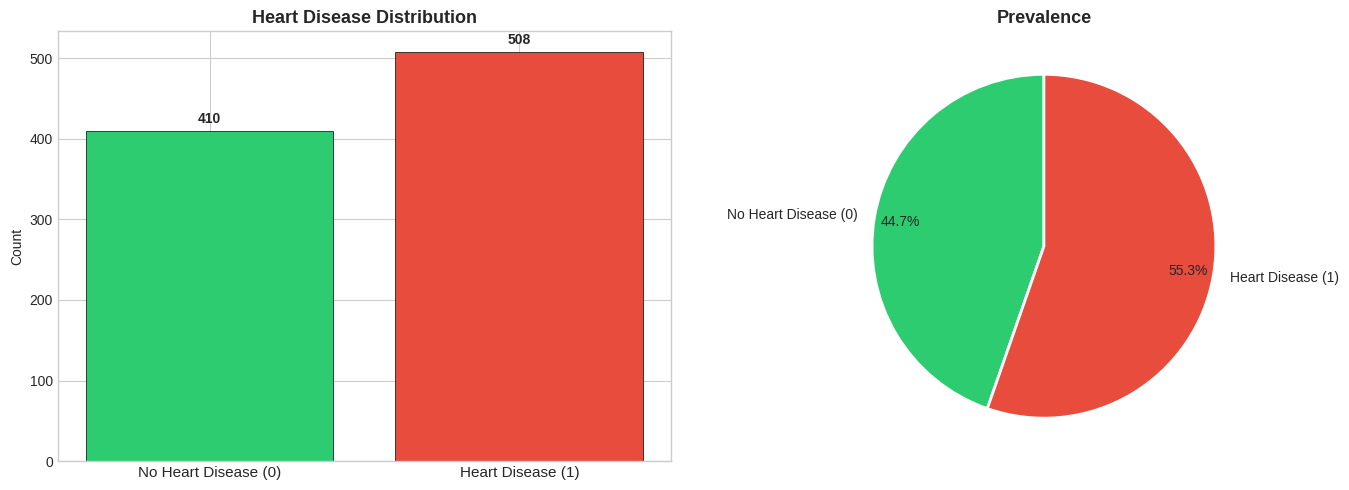

AU context: CVD is Australia's leading cause of death (~42,300 deaths/year, AIHW).
1 in 4 Australians have CVD. Medicare Heart Health Check (item 699) targets early detection.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['No Heart Disease (0)', 'Heart Disease (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Heart Disease Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: CVD is Australia's leading cause of death (~42,300 deaths/year, AIHW).")
print("1 in 4 Australians have CVD. Medicare Heart Health Check (item 699) targets early detection.")


## 3. Exploratory Data Analysis

Key clinical questions:
- Which clinical features most strongly predict heart disease?
- Do chest pain type and exercise-induced angina show clear separation?
- Are there age/sex differences in disease prevalence?
- How do resting BP, cholesterol, and max heart rate interact?


Numeric features (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


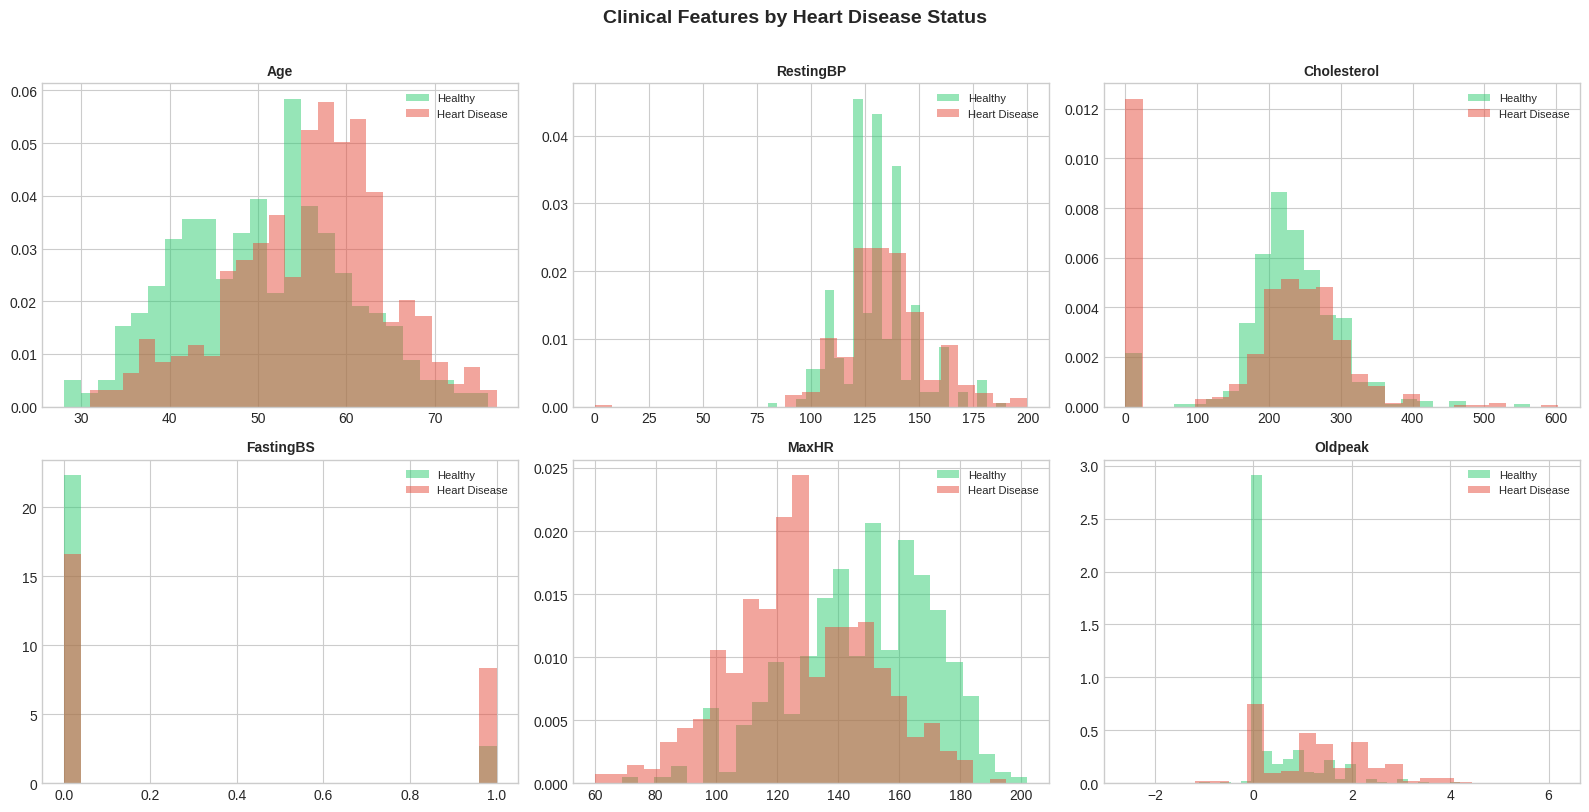

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:6]
n_rows_p = (len(plot_cols) + 2) // 3
fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Healthy', 'Heart Disease']):
        subset = df[df[target_col] == label][col].dropna()
        if len(subset) > 0:
            axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
    axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Clinical Features by Heart Disease Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


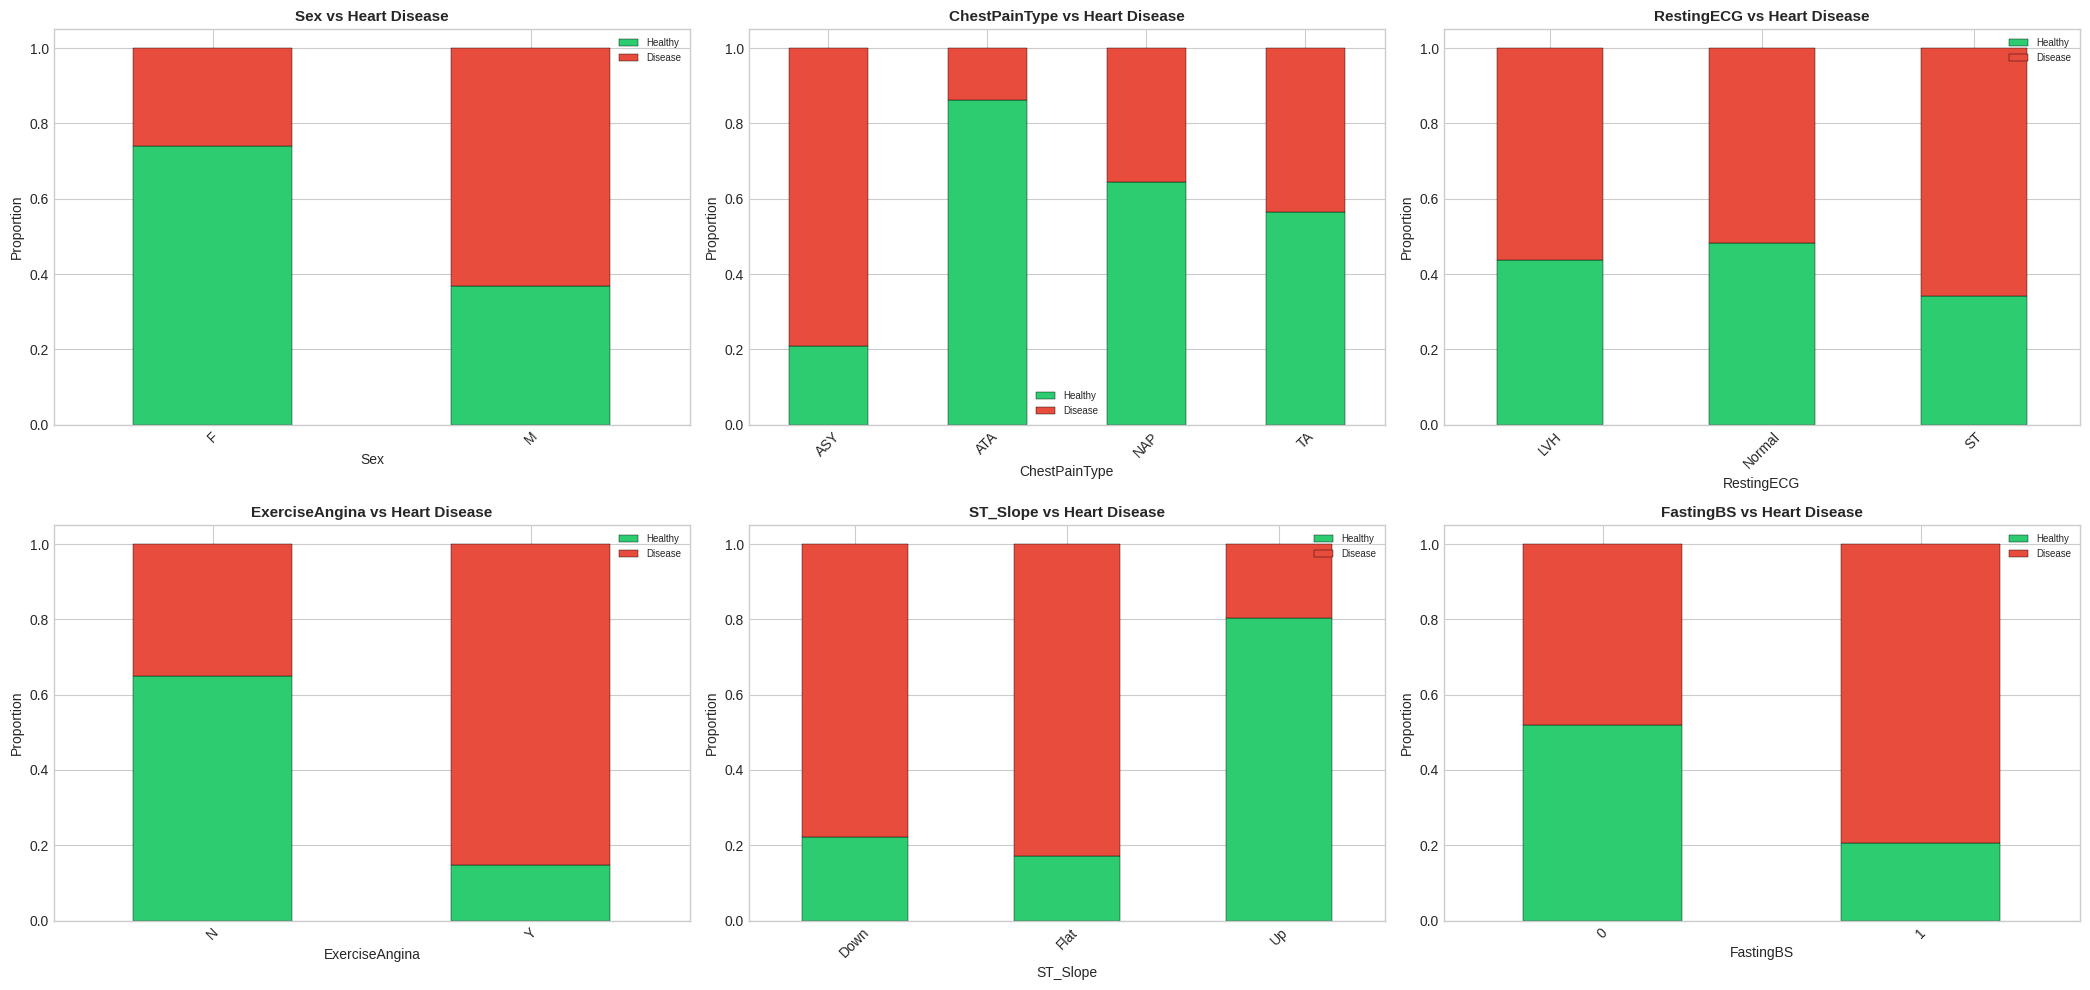

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
# Also include low-cardinality numeric as categorical for analysis
binary_num = [c for c in numeric_cols if df[c].nunique() <= 5]
plot_cats = cat_cols + binary_num
plot_cats = plot_cats[:6]

if len(plot_cats) > 0:
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Heart Disease', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion'); axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['Healthy', 'Disease'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


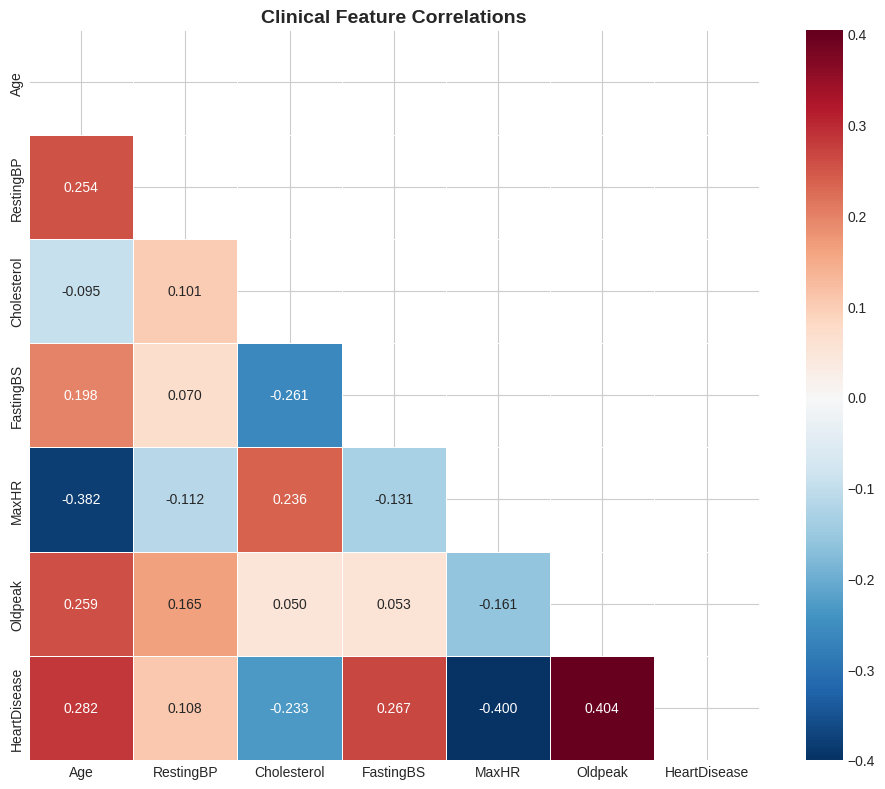

Correlations with heart disease:
  Oldpeak                   +0.4040
  MaxHR                     -0.4004
  Age                       +0.2820
  FastingBS                 +0.2673
  Cholesterol               -0.2327
  RestingBP                 +0.1076


In [8]:
corr = df[numeric_cols + [target_col]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Clinical Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
print("Correlations with heart disease:")
for feat, val in target_corr.items():
    direction = "+" if corr.loc[feat, target_col] > 0 else "-"
    print(f"  {feat:25s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Encode categorical columns
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes -> {list(le.classes_)}")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Handle any missing values
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
    print("Imputed missing values with median")

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


  Encoded 'Sex': 2 classes -> ['F', 'M']
  Encoded 'ChestPainType': 4 classes -> ['ASY', 'ATA', 'NAP', 'TA']
  Encoded 'RestingECG': 3 classes -> ['LVH', 'Normal', 'ST']
  Encoded 'ExerciseAngina': 2 classes -> ['N', 'Y']
  Encoded 'ST_Slope': 3 classes -> ['Down', 'Flat', 'Up']

Feature matrix: (918, 11)
Target: {np.int64(0): np.int64(410), np.int64(1): np.int64(508)}


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Blood pressure risk category
if 'RestingBP' in feature_names:
    X['bp_high'] = (X['RestingBP'] >= 140).astype(int)
    composites_added.append('bp_high')
    print("Created 'bp_high' (RestingBP >= 140)")

# Cholesterol risk
if 'Cholesterol' in feature_names:
    X['cholesterol_high'] = (X['Cholesterol'] > 240).astype(int)
    # Handle zero cholesterol (likely missing/placeholder)
    X['cholesterol_zero'] = (X['Cholesterol'] == 0).astype(int)
    composites_added.extend(['cholesterol_high', 'cholesterol_zero'])
    print("Created 'cholesterol_high' (>240) and 'cholesterol_zero' flag")

# Age-MaxHR interaction (age-adjusted cardiac capacity)
if 'Age' in feature_names and 'MaxHR' in feature_names:
    X['age_maxhr_ratio'] = X['Age'] / (X['MaxHR'] + 1)
    composites_added.append('age_maxhr_ratio')
    print("Created 'age_maxhr_ratio'")

# Multi-risk factor count
risk_cols = []
if 'RestingBP' in feature_names: risk_cols.append('bp_high')
if 'Cholesterol' in feature_names: risk_cols.append('cholesterol_high')
if 'FastingBS' in feature_names: risk_cols.append('FastingBS')
if len(risk_cols) >= 2:
    X['risk_factor_count'] = X[risk_cols].sum(axis=1)
    composites_added.append('risk_factor_count')
    print(f"Created 'risk_factor_count' from {risk_cols}")

print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'bp_high' (RestingBP >= 140)
Created 'cholesterol_high' (>240) and 'cholesterol_zero' flag
Created 'age_maxhr_ratio'
Created 'risk_factor_count' from ['bp_high', 'cholesterol_high', 'FastingBS']

Total engineered: 5
Final feature count: 16


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8464  F1=0.8571  AUC=0.9086
  Fold 2: Acc=0.8562  F1=0.8690  AUC=0.9171
  Fold 3: Acc=0.8529  F1=0.8747  AUC=0.9246
  -- Acc: 0.8519  F1: 0.8669  AUC: 0.9168  Time: 0.95s

Training: Random Forest
  Fold 1: Acc=0.8725  F1=0.8822  AUC=0.9290
  Fold 2: Acc=0.8660  F1=0.8812  AUC=0.9304
  Fold 3: Acc=0.8562  F1=0.8771  AUC=0.9149
  -- Acc: 0.8649  F1: 0.8801  AUC: 0.9248  Time: 1.37s

Training: XGBoost
  Fold 1: Acc=0.8693  F1=0.8788  AUC=0.9228
  Fold 2: Acc=0.8431  F1=0.8629  AUC=0.9198
  Fold 3: Acc=0.8399  F1=0.8635  AUC=0.9186
  -- Acc: 0.8508  F1: 0.8684  AUC: 0.9204  Time: 0.36s

Training: LightGBM
  Fold 1: Acc=0.8660  F1=0.8761  AUC=0.9279
  Fold 2: Acc=0.8529  F1=0.8711  AUC=0.9206
  Fold 3: Acc=0.8562  F1=0.8757  AUC=0.9182
  -- Acc: 0.8584  F1: 0.8743  AUC: 0.9222  Time: 0.35s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
      Random Forest 0.8649 +/- 0.0067 0.8801 +/- 0.0022 0.9248 +/- 0.0070 0.1066 1.37s
           LightGBM 0.8584 +/- 0.0056 0.8743 +/- 0.0023 0.9222 +/- 0.0041 0.1139 0.35s
            XGBoost 0.8508 +/- 0.0132 0.8684 +/- 0.0074 0.9204 +/- 0.0018 0.1197 0.36s
Logistic Regression 0.8519 +/- 0.0041 0.8669 +/- 0.0073 0.9168 +/- 0.0065 0.1128 0.95s

Best model: Random Forest


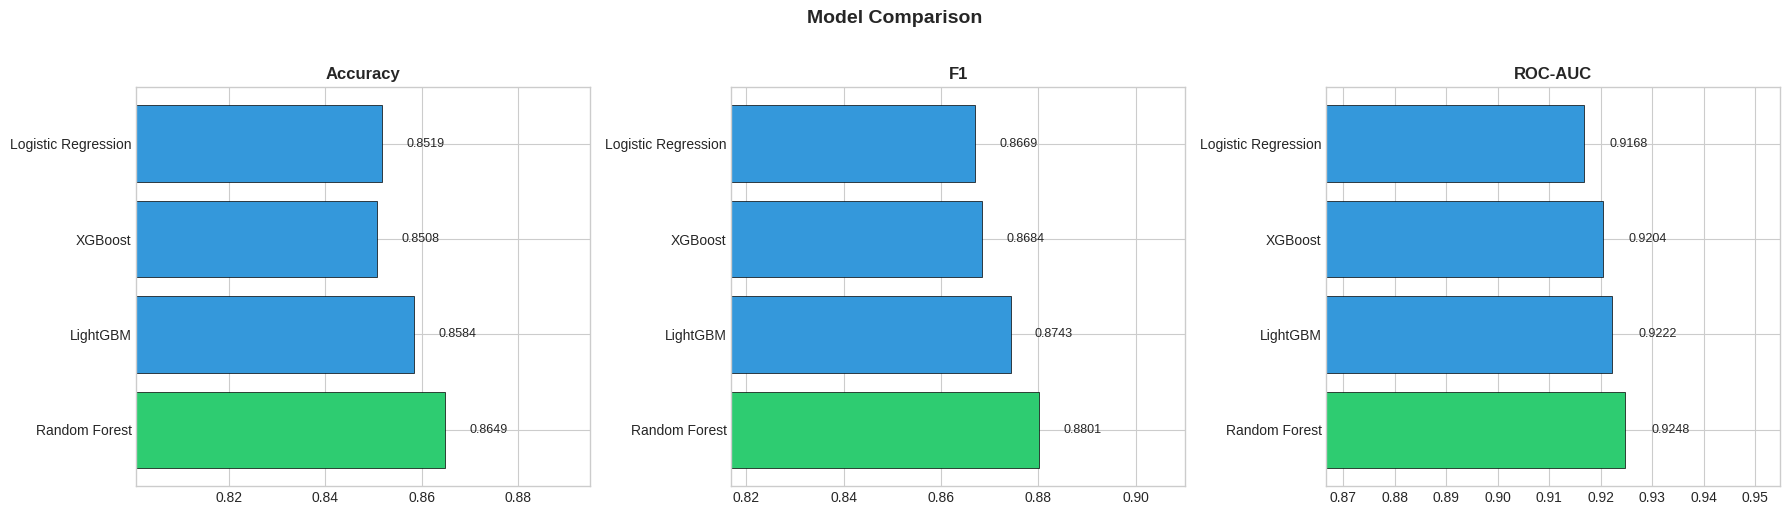

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For cardiac screening:
- **False negatives** (missed heart disease) = delayed treatment, potential cardiac event
- **False positives** (flagging healthy) = unnecessary cardiology referral — but clinically safer
- Clinical screening should bias toward sensitivity (catch more cases)


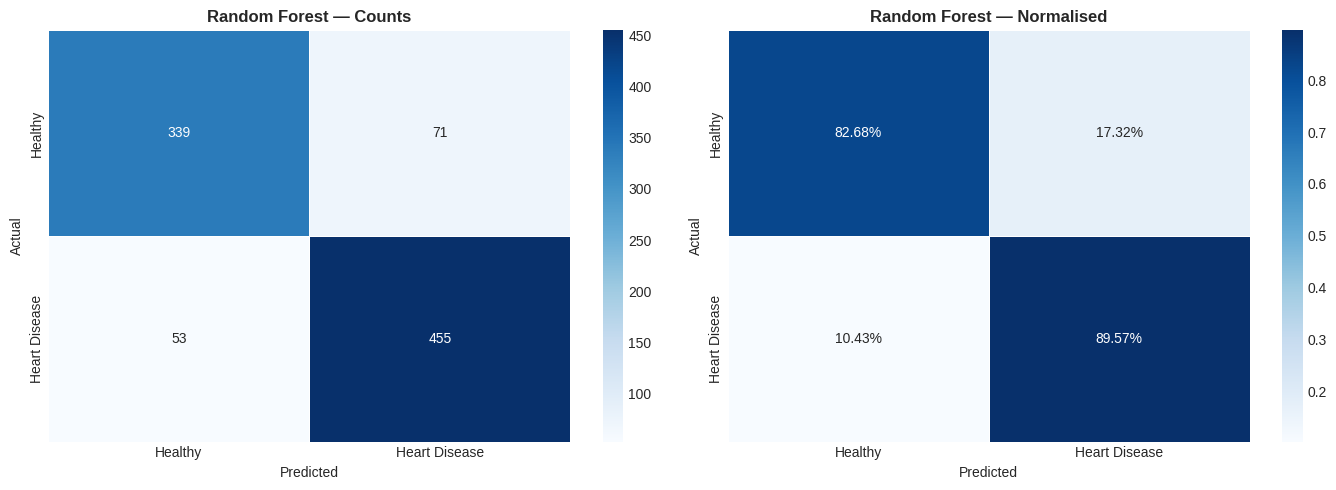


               precision    recall  f1-score   support

      Healthy       0.86      0.83      0.85       410
Heart Disease       0.87      0.90      0.88       508

     accuracy                           0.86       918
    macro avg       0.86      0.86      0.86       918
 weighted avg       0.86      0.86      0.86       918



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Healthy', 'Heart Disease']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


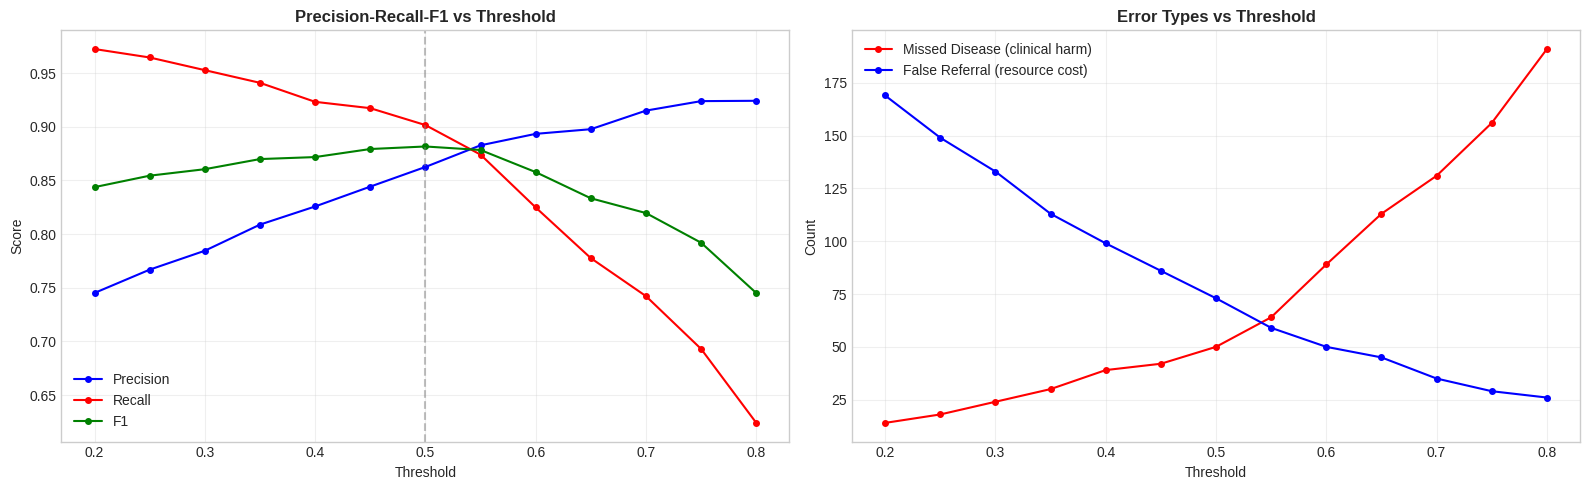


Optimal threshold (F1): 0.50
For screening, consider lower threshold (0.35-0.40) to maximise sensitivity.


In [16]:
thresholds = np.arange(0.20, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Disease (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Referral (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Disease (FN)'], 'r-o', ms=4, label='Missed Disease (clinical harm)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Referral (FP)'], 'b-o', ms=4, label='False Referral (resource cost)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"For screening, consider lower threshold (0.35-0.40) to maximise sensitivity.")


## 8. Feature Importance & Policy Insights

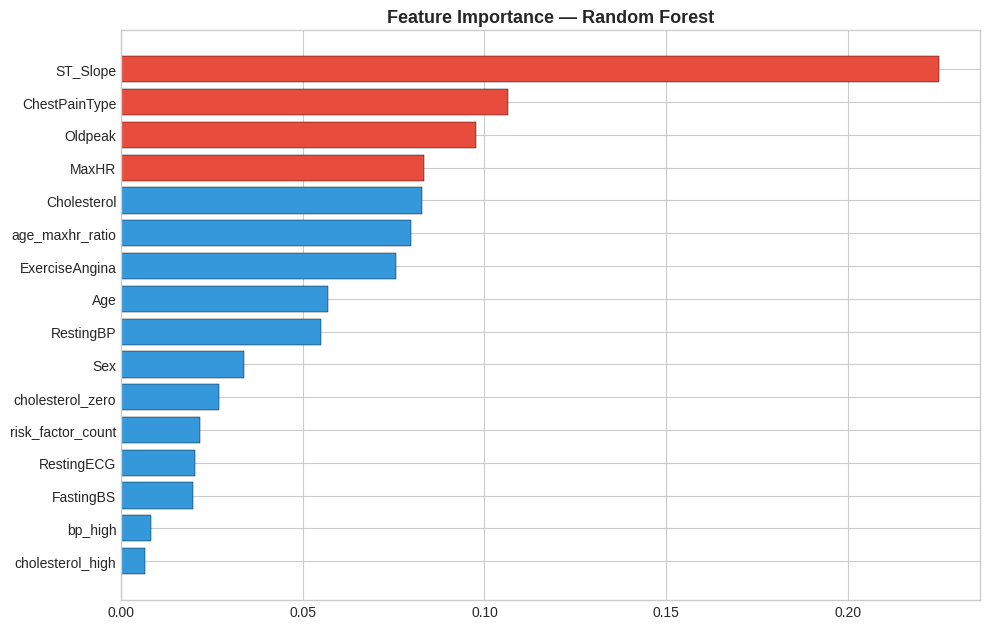

TOP 5 CLINICAL PREDICTORS
  ST_Slope                   0.2252
  ChestPainType              0.1065
  Oldpeak                    0.0978
  MaxHR                      0.0833
  Cholesterol                0.0828


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 CLINICAL PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")


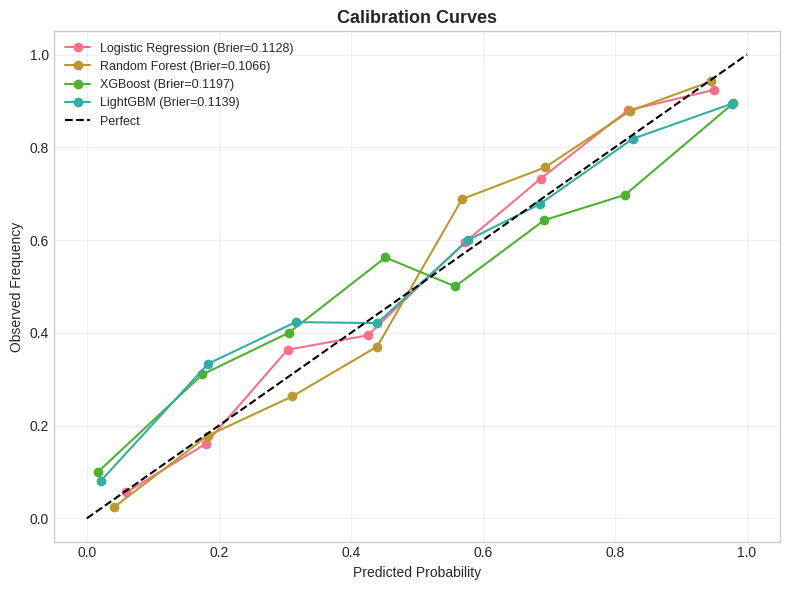

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.70': best_res['f1_mean'] > 0.70,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  ROC-AUC:              0.9248
  F1:                   0.8801
  Precision:            0.8667
  Recall:               0.8956
  Brier Score:          0.1066
  Training time:        1.4s
  Feature count:        16
  Dataset rows:         918
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.50

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.80
  [pass] F1 > 0.70
  [pass] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: GP clinical systems (Best Practice / Medical Director), My Health Record
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (pathology, vitals, ECG results)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Risk score + contributing factors + recommended action
   Batch: Quarterly PHN cardiovascular risk stratification

3. INTEGRATION POINTS
   GP desktop: Risk score in patient summary (Best Practice plugin)
   Medicare: Trigger for Heart Health Check (item 699) eligibility
   PHN dashboard: Population CVD risk heatmap by LGA
   Specialist referral: Auto-generate cardiology referral for high risk
   My Health Record: Risk assessment as shared health summary

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device (SaMD) classification
   Validation: Prospective study with cardiology gold standard
   Explainability: Feature contributions shown to clinician
   Consent: Patient informed consent for ML-assisted screening
   RACGP: Alignment with Red Book preventive care guidelines
   Equity: Monitor across Indigenous, CALD, rural/remote populations

5. MONITORING & RETRAINING
   Drift: PSI on clinical features quarterly
   Performance: AUC on confirmed diagnoses (echocardiography/angiography)
   Retraining: Annual with confirmed cardiac outcomes
   Clinical guidelines: Recalibrate when NHFA/RACGP guidelines change

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: GP clinical systems (Best Practice / Medical Director), My Health Record
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (pathology, vitals, ECG results)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Risk score + contributing factors + recommended action
   Batch: Quarterly PHN cardiovascular risk stratification

3. INTEGRATION POINTS
   GP desktop: Risk score in patient summary (Best Practice plugin)
   Medicare: Trigger for Heart Health Check (item 699) eligibility
   PHN dashboard: Population CVD risk heatmap by LGA
   Specialist referral: Auto-generate cardiology referral for high risk
   My Health Record: Risk assessment as shared health summary

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device 